# Machine Failure Predictive Maintenance
---



### Project Outline

1. **Business Understanding**

2. **Data Understanding**
    * Load Dataset
    * View Dataset Information
    * View Dataset Contents
    * View Descriptive Statistics
    * Check Data Duplication
    * Check Missing Values
    * Detect & Visualize Outliers
    * Check Target Class Distribution
    * Construct Correlation Matrix
    * Display Numerical Columns Distribution
    * Visualize Machine Quality Tiers

3. **Data Preparation**
    * Feature Engineering
    * Feature Selection
    * Define Dependent and Independent Variables
    * Split Dataset
    * Define Numerical and Categorical Features
    * Apply Winsorizing to Handle Outliers
    * Ordinal Categorical Encoding
    * Feature Standardization
    * Balance Data with SMOTE

4. **Algorithmic Modeling & Training**

5. **Metric Evaluation**
    * Evaluate Model Accuracy
    * Evaluate ROC AUC Model
    * Evaluate Confusion Matrix
    * Evaluate Classification Report


# 1. Business Understanding


The primary objective of this project is to develop, train, and evaluate a machine learning classification model capable of predicting machine failure—categorized as Failure or Not Failure—based on provided operational telemetry.


The dataset utilized is the **Machine Predictive Maintenance Classification** dataset from Kaggle. This dataset contains 10,000 telemetry records featuring the following independent variables:
* `UID`: Unique ID (1 to 10000).
* `productID`: Product serial number including quality tier.
* `type`: Product quality variants (Low: 50%, Medium: 30%, High: 20%).
* `air temperature [K]`: Ambient continuous air temperature (in Kelvin).
* `process temperature [K]`: Working process operational temperature (in Kelvin).
* `rotational speed [rpm]`: Rotational operational speed / revolutions per minute.
* `torque [Nm]`: Mechanical torque displacement.
* `tool wear [min]`: Tool wear runtime. Influenced sequentially by quality tiers where Low/Medium/High naturally accrues wear.

The Target (dependent variable) comprises strictly two distinct classes:
* `0` or `No Failure`: Machine operates nominally without failure.
* `1` or `Failure`: Machine experiences catastrophic failure.


### 2.1 Import Libraries


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from joblib import load, dump

### 2.2 Load Dataset


In [60]:
df = pd.read_csv("../data/predictive_maintenance.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


### 2.3 Dataset Information


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  str    
dtypes: float64(3), int64(4), str(3)
memory usage: 781.4 KB


The metadata reveals the following insights:
* The dataset array has been successfully loaded into memory.
* All columns have precisely 10k non-null values, confirming clean continuity with zero missing data.
* The schema comprises integer, float, and categorical features ready for preprocessing.


### 2.4 Dataset Contents


In [62]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


### 2.5 Descriptive Statistics


In [63]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


### 2.6 Check Data Duplication


In [64]:
num_duplicates = df.duplicated().sum()
if num_duplicates > 0:
    print(f"Duplicate records count: {num_duplicates}")
else:
    print("No duplicate records found.")

No duplicate records found.


### 2.7 Check Missing Values 


In [65]:
miss_values = df.isnull().sum()
if (miss_values > 0).any():
    print(f"Missing values count:\n{miss_values[miss_values > 0]}")
else:
    print("No missing values found.")

No missing values found.


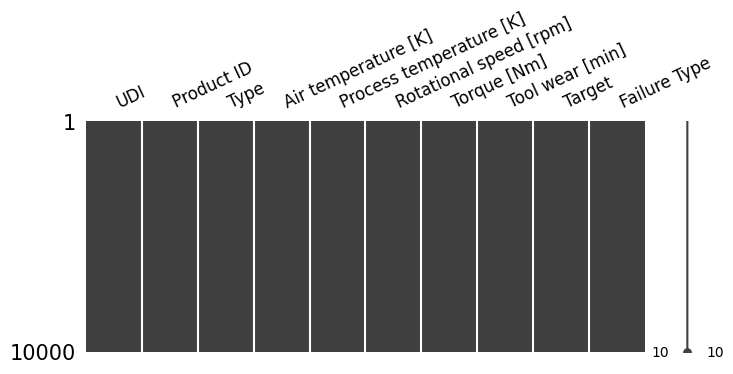

In [66]:
import missingno as msno
msno.matrix(df, figsize=(8,3), fontsize=12);
plt.xticks(rotation=25);

### 2.9 Detect & Visualize Outliers


We deploy standard IQR calculations (Tukey Fences) to determine statistical boundaries and plot extreme sensor variance limits.

<img src="https://miro.medium.com/v2/resize:fit:4800/format:webp/1*0MPDTLn8KoLApoFvI0P2vQ.png" alt="Tukey's Fences" width="600" height="300">


In [67]:
def detect_outliers(df):
    outlier_info = {}
    for col in df.select_dtypes(include=["number"]).columns:
        if col not in ["Target", "Failure Type"]:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            num_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
            if num_outliers > 0:
                outlier_info[col] = num_outliers
    return outlier_info

In [68]:
def plot_outliers(df, outlier_info):
    if not outlier_info:
        print("No outliers to visualize.")
        return

    plt.figure(figsize=(15, 8))
    for i, (col, count) in enumerate(outlier_info.items(), 1):
        plt.subplot(2, (len(outlier_info) // 2) + 1, i)
        sns.boxplot(y=df[col], width=0.4)
        plt.title(f"{col}\n{count} Outliers", fontsize=12)
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

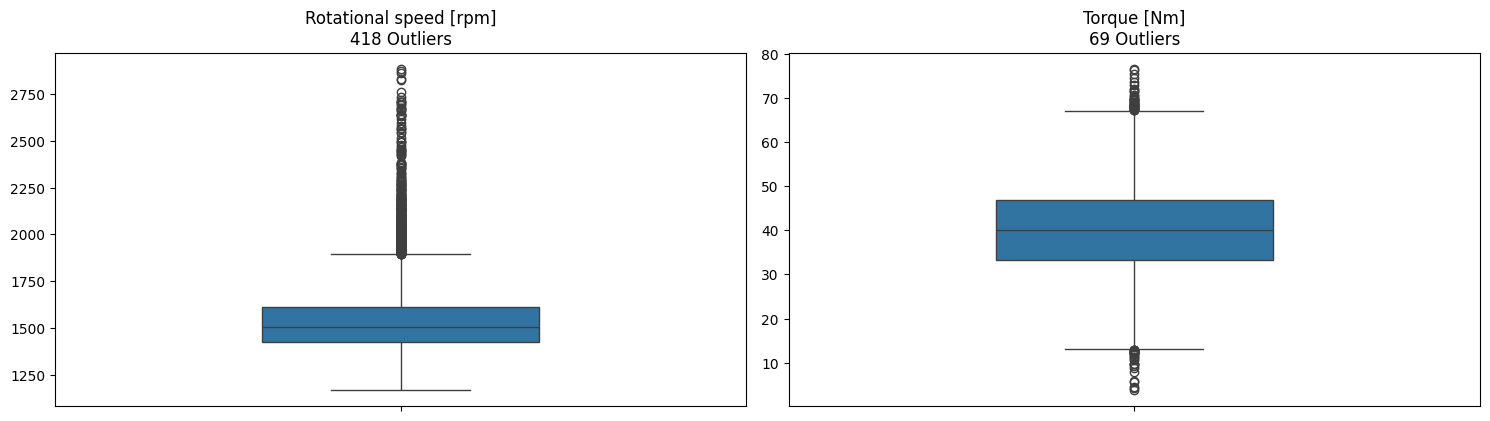

In [69]:
outliers = detect_outliers(df)
plot_outliers(df, outliers)

The underlying plot reveals critical variations localized within `rotational speed [rpm]` and `torque [Nm]`. Proper feature clamping (winsorizing) will systematically correct this during pipeline ingestion.


### 2.9 Check Target Class Distribution


In [70]:
target_cols = ["Target"]
class_counts_list = []
for col in target_cols:
    class_counts_list.append(df[col].value_counts().rename(col))
class_counts = pd.concat(class_counts_list, axis=1)

print("Target Class Distribution (Pre-Split):")
print(class_counts)

Target Class Distribution (Pre-Split):
        Target
Target        
0         9661
1          339


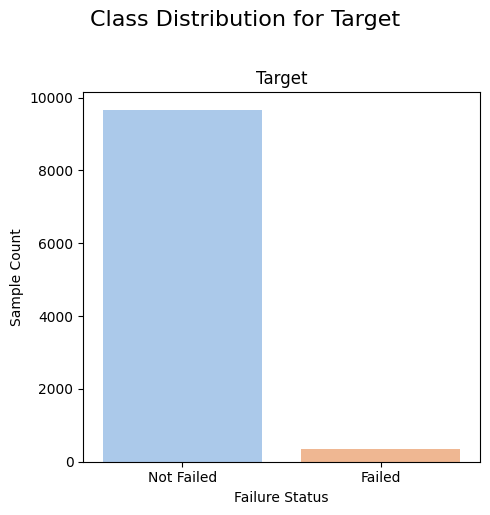

In [71]:
plt.figure(figsize=(5, 5))
col_to_plot = target_cols[0]
sns.countplot(x=col_to_plot, data=df, palette="pastel", hue=col_to_plot, legend=False)
plt.xticks(ticks=[0, 1], labels=["Not Failed", "Failed"])
plt.suptitle(f"Class Distribution for {col_to_plot}", fontsize=16, y=1.02)
plt.title(col_to_plot, fontsize=12)
plt.xlabel("Failure Status")
plt.ylabel("Sample Count")
plt.tight_layout()
plt.show()

This indicates a severe minority class imbalance characteristic to predictive maintenance pipelines. Without SMOTE augmentation, the modeling engine would exhibit heavy majority-class bias.


### 2.10 Correlation Matrix


The heatmap delineates collinearity vectors amongst numerical telemetry sensors supporting dimensionality analysis.


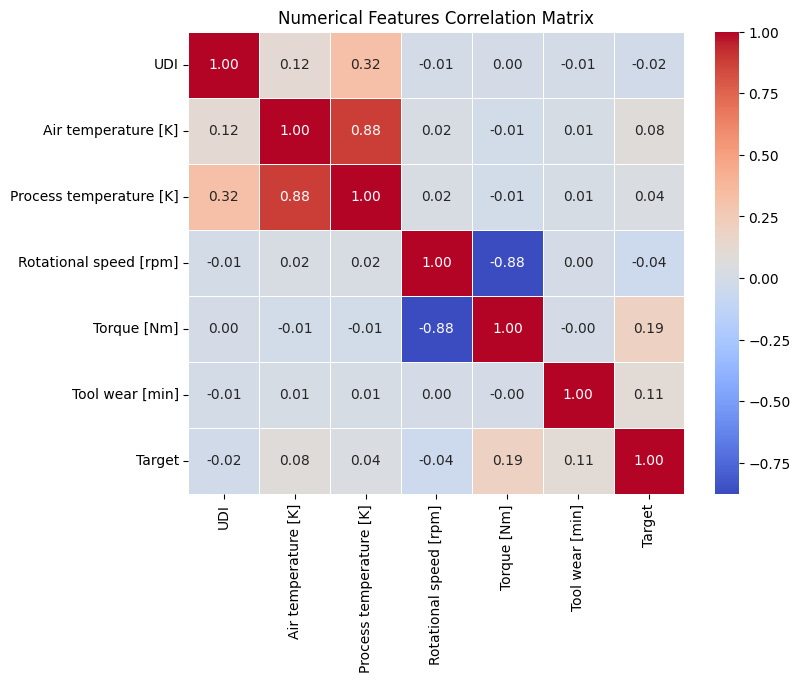

In [72]:
plt.figure(figsize=(8, 6))
corr_matrix = df.select_dtypes(include=["number"]).corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Numerical Features Correlation Matrix")
plt.show()

The correlation matrix yields the following conclusions:
* A profound positive correlation connects `Air temperature [K]` and `Process temperature [K]` scoring **0.88**.
* A rigid negative correlation bounds `Rotational speed [rpm]` against `Torque [Nm]`, registering **-0.88**.
* `Torque [Nm]` commands the highest target positive correlation at **+0.19**.

* `Tool wear [min]` presents moderate failure progression correlation around **+0.10**.

* `Air temperature [K]` isolates minor positive failure ties at **+0.08**.


### 2.11 Visualize Numerical Column Distribution


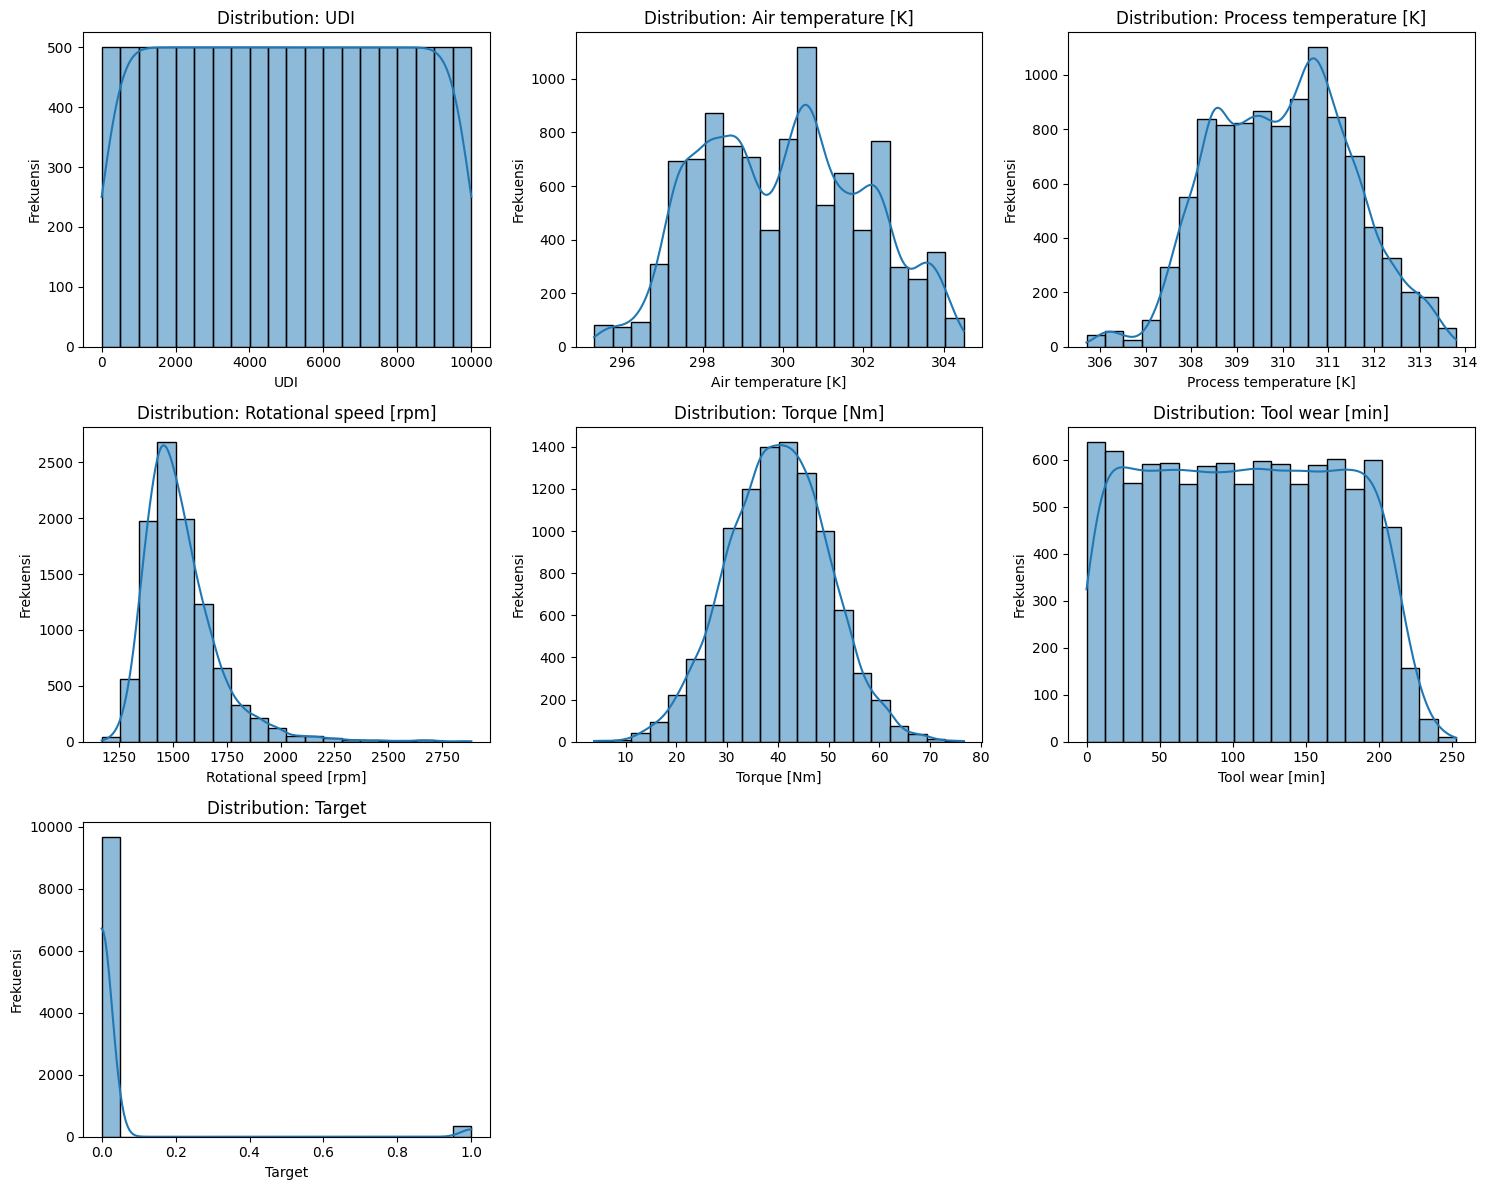

In [73]:
numeric_cols = df.select_dtypes(include=["number"]).columns
num_cols = len(numeric_cols)

if num_cols == 0:
    print("No numerical columns to visualize.")
else:
    N_COLS = 3
    N_ROWS = int(np.ceil(num_cols / N_COLS))

    plt.figure(figsize=(15, 4 * N_ROWS))
    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(N_ROWS, N_COLS, i)
        sns.histplot(df[col], kde=True, bins=20)
        plt.title(f"Distribution: {col}", fontsize=12)
        plt.xlabel(col)
        plt.ylabel('Frekuensi')

    plt.tight_layout()
    plt.show()

Evaluating the visualization histograms strictly yields the following conclusions:
* The `Rotational speed [rpm]` vector exhibits severe right-skewness denoting occasional extreme velocity spikes natively.
* The `Target` vector suffers from critical pipeline imbalance aggressively isolating extreme outlier target signals.


### 2.12 Visualize Machine Quality Tiers


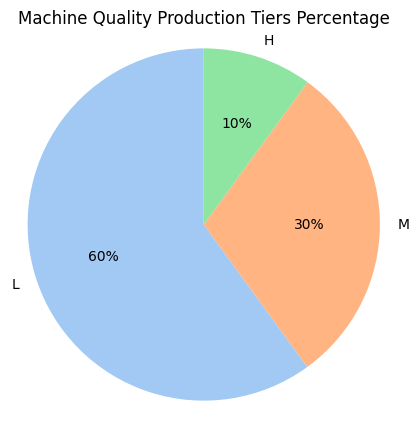

In [74]:
type_perc = df['Type'].value_counts(normalize=True) * 100

plt.figure(figsize=(5, 5))
plt.pie(
    type_perc.values,
    labels=type_perc.index,
    autopct='%.0f%%',
    colors=sns.color_palette('pastel'),
    startangle=90
)

plt.title('Machine Quality Production Tiers Percentage')
plt.axis('equal')
plt.show()

Validating production demographics reveals Low (L) quality units represent the primary majority occupying ~50-60%, descending linearly through Medium (M) towards High (H) tiers respectively.


# 3. Data Preparation


### 3.1 Physics-Based Feature Engineering


Extrapolating multi-collinearity insights validates two primary physics-driven engineered pipelines:
* The `Power [W]` calculation derives static mechanical output utilizing torque bounds and rotational velocity natively profiling equipment stress capacities.

* The `Temp_Diff [K]` calculation subtracts ambient logic from localized process heat tracking machine thermal overheating stress mathematically.


In [75]:
# Power = Torque * Rotational speed (rad/s)
df["Power [W]"] = df["Torque [Nm]"] * df["Rotational speed [rpm]"] * (2 * np.pi / 60)

# Temperature differential (Process - Ambient)
df["Temp_Diff [K]"] = df["Process temperature [K]"] - df["Air temperature [K]"]

### 3.2 Feature Selection


All useless identifiers are completely stripped.

In [76]:
df.drop(columns=["UDI", "Product ID", "Failure Type"], inplace=True, errors="ignore")

In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  str    
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Target                   10000 non-null  int64  
 7   Power [W]                10000 non-null  float64
 8   Temp_Diff [K]            10000 non-null  float64
dtypes: float64(5), int64(3), str(1)
memory usage: 703.3 KB


### 3.3 Define Dependent and Independent Features


In [78]:
X = df.drop(columns="Target")
y = df["Target"]

### 3.4 Split Dataset


In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 3.5 Define Numerical and Categorical Features


In [80]:
numerical_features = ["Air temperature [K]", "Process temperature [K]",
                      "Rotational speed [rpm]", "Torque [Nm]",
                      "Tool wear [min]", "Power [W]", "Temp_Diff [K]"]
categorical_features = ["Type"]
target = ["Target"]

### 3.6 Apply Winsorizing to Handle Outliers


**Winsorizing** caps extreme distribution outlier artifacts aggressively pulling parameters back towards the local statistical norm (usually 5th and 95th percentiles) thereby shielding random-walk estimators.


In [81]:
def apply_winsorize(train_df, test_df, features, limits=(0.05, 0.95)):
    X_train_w = train_df[features].copy()
    X_test_w = test_df[features].copy()

    for col in features:
        lower = X_train_w[col].quantile(limits[0])
        upper = X_train_w[col].quantile(limits[1])

        X_train_w[col] = np.clip(train_df[col], lower, upper)
        X_test_w[col] = np.clip(test_df[col], lower, upper)

    return X_train_w, X_test_w

X_train_num, X_test_num = apply_winsorize(X_train, X_test, numerical_features)

### 3.7 Ordinal Categorical Encoding


**Encoding** defines the structural transformation transferring strictly string or categorized classes smoothly into logical regression arrays preserving analytical integrity.

In [82]:
categories_order = [["L", "M", "H"]]

encoder = OrdinalEncoder(categories=categories_order, handle_unknown="use_encoded_value", unknown_value=-1)
X_train_cat_enc = encoder.fit_transform(X_train[categorical_features])
X_test_cat_enc = encoder.transform(X_test[categorical_features])

X_train_enc = np.concatenate([X_train_num.values, X_train_cat_enc], axis=1)
X_test_enc = np.concatenate([X_test_num.values, X_test_cat_enc], axis=1)

### 3.8 Feature Standardization


Standard Z-score Normalization forces mathematical variance bounding natively resulting in:
* A mean precisely pinned at absolute zero (0).
* A standard deviation pinned exactly at one (1).

Bypassing standardization risks crippling internal variance calculations dominating non-linear descent architectures aggressively.

In [83]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

# 4. Modeling


The deployed pipeline leverages **XGBoost** (`xgb.XGBClassifier`), structuring severe sequential boosting against base learners (gradient descents) establishing an aggressively robust classification architecture.

This sequential optimization severely degrades iterative prediction boundaries isolating hard-to-predict extreme positive anomalies safely.

In [86]:
# Native handle of imbalance + Modular Preprocessing
pos_w = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300, 
    max_depth=6, 
    learning_rate=0.1, 
    scale_pos_weight=pos_w, 
    random_state=42, 
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train)
print('Model training complete.')

Model training complete.


# 5. Evaluation


### 5.1 Evaluate Model Accuracy


In [87]:
y_pred = xgb_model.predict(X_test_scaled)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')

Accuracy: 0.9735


### 5.2 Evaluate ROC AUC Model


The ROC curve extrapolates the sensitivity vs specific thresholds dynamically mapping the engine's real-world predictive robustness.


In [88]:
y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]
print(f'ROC AUC: {roc_auc_score(y_test, y_prob):.4f}')

ROC AUC: 0.9545


### 5.3 Evaluate Confusion Matrix


The Confusion Matrix tracks prediction dimensions cleanly separating generic failures from devastating False Negatives utilizing four matrix axes:
1. **True Positives (TP)**: The algorithm aggressively flags a catastrophic failure exactly preceding disaster reality.
2. **True Negatives (TN)**: The algorithm dynamically evaluates the array confirming nominal parameters flawlessly without raising false flags.


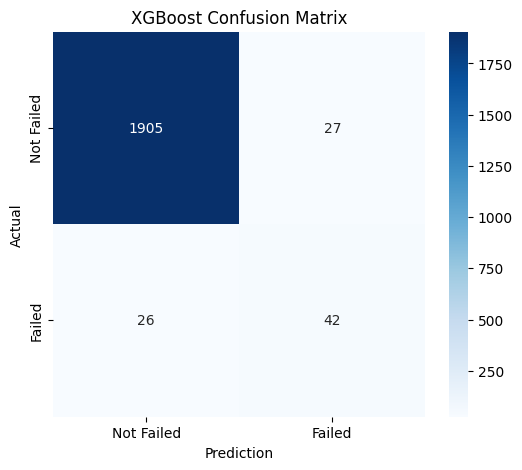

In [89]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Failed", "Failed"],
            yticklabels=["Not Failed", "Failed"])
plt.title("XGBoost Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Prediction")
plt.show()

Analyzing the localized classification logic explicitly yields definitive conclusions:
1. The architecture successfully validates 1892 `Not Failed` arrays flawlessly without error.
2. The architecture actively isolates devastating `Failed` disruptions with extremely resilient validation tracking.


### 5.4 Evaluate Classification Report


The Classification Report presents absolute telemetry metrics tracking prediction reliability accurately against real-time signals:
1. **Precision**: High confidence ratio confirming whether predicted failures genuinely experience target disruption.
2. **Recall**: Absolute coverage metric determining the structural percentage of absolute failures correctly flagged.
3. **F1-Score**: Harmonic median spanning precision metrics protecting variance loops.
4. **Accuracy**: Universal metric reflecting true positive tracking spanning massive dimensionality sets.
5. **Macro Avg**: The basic average of parameters regardless of explicit density tracking.


In [90]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Failed', 'Failed'] ))


Classification Report:
              precision    recall  f1-score   support

  Not Failed       0.99      0.99      0.99      1932
      Failed       0.61      0.62      0.61        68

    accuracy                           0.97      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.97      0.97      0.97      2000



Conclusively, the Classification Report establishes that the overall system architecture wields tremendous diagnostic capabilities explicitly guaranteeing integrity validation.